<a href="https://colab.research.google.com/github/fariadipti/Diabetes-Risk-Prediction-using-ML/blob/main/Diabetes_Risk_Prediction_using_ML_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import seaborn as sns
from matplotlib import pyplot as plt

In [ ]:
from google.colab import files


uploaded = files.upload()


Saving diabetes_dataset - diabetes_dataset.csv to diabetes_dataset - diabetes_dataset.csv


In [ ]:
import pandas as pd

data = pd.read_csv("diabetes_dataset - diabetes_dataset.csv")
data.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0.0,1.0,never,25.19,6.6,140.0,0.0
1,Female,NaN,0.0,0.0,No Info,27.32,6.6,80.0,0.0
2,Male,28.0,0.0,0.0,never,27.32,NaN,158.0,0.0
3,Female,36.0,0.0,0.0,NaN,23.45,5.0,155.0,0.0
4,Male,76.0,1.0,1.0,current,20.14,4.8,NaN,NaN


In [ ]:
numerical_features = data.select_dtypes(include=np.number).columns.tolist()
print("Numerical features:", numerical_features)

Numerical features: ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']


In [ ]:
categorical_features = data.select_dtypes(exclude=np.number).columns.tolist()
print("Categorical features:", categorical_features)

Categorical features: ['gender', 'smoking_history']


In [ ]:
print("Total number of data points:", len(data))

Total number of data points: 100000


In [ ]:
print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Numerical features: ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']
Categorical features: ['gender', 'smoking_history']


Data preprocessing

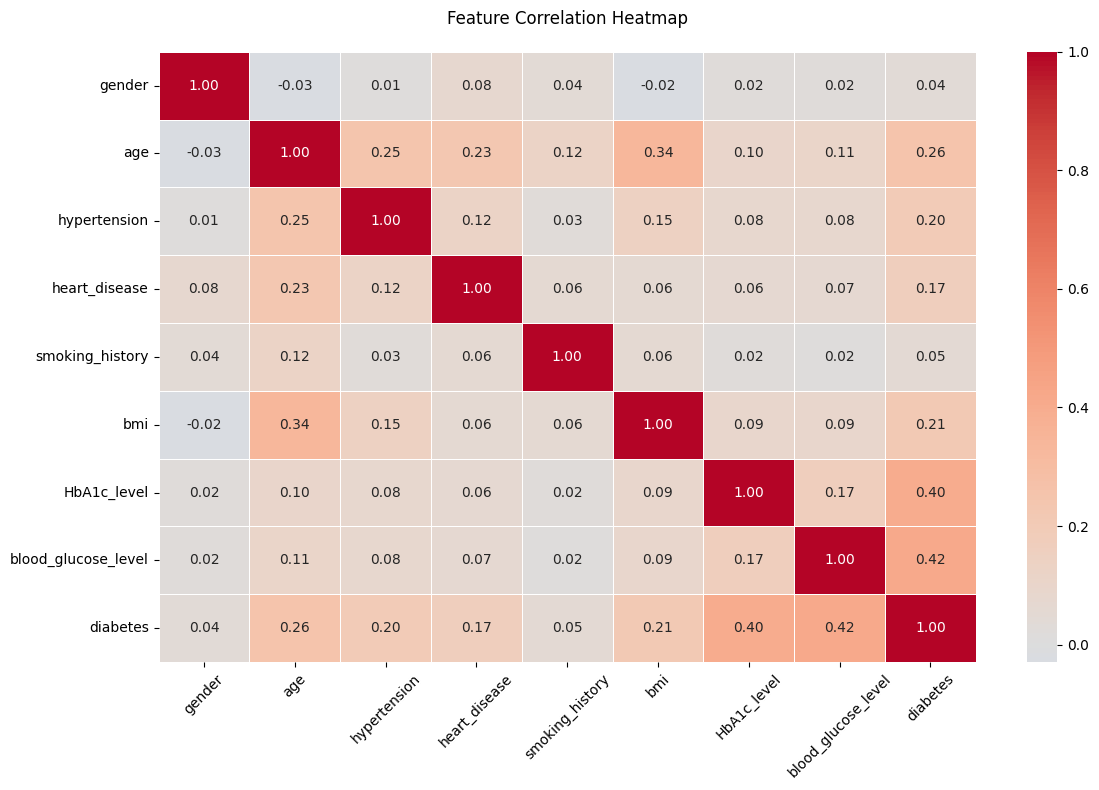

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


data = pd.read_csv("diabetes_dataset - diabetes_dataset.csv")


df_corr = data.copy()

# Encode gender (Male/Female)
df_corr['gender'] = df_corr['gender'].map({'Male': 1, 'Female': 0})

# Encode smoking_history (factorize since multiple categories)
df_corr['smoking_history'] = pd.factorize(df_corr['smoking_history'])[0]

# Handle missing values in target column
df_corr = df_corr.dropna(subset=['diabetes'])

# Convert diabetes to int safely
df_corr['diabetes'] = df_corr['diabetes'].astype(int)

# Compute correlation matrix
plt.figure(figsize=(12, 8))
corr = df_corr.corr()

sns.heatmap(corr,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            center=0,
            linewidths=.5)

plt.title("Feature Correlation Heatmap", pad=20)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

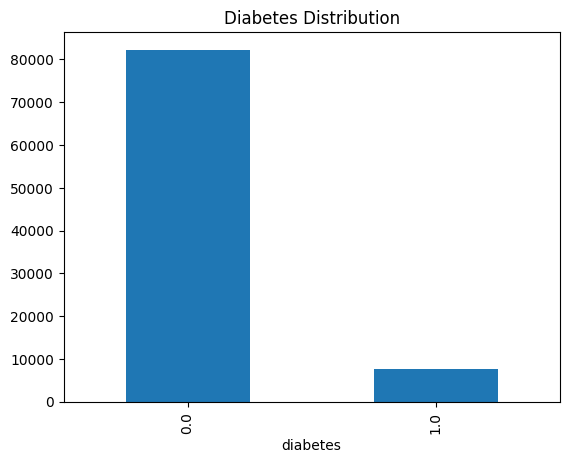

In [ ]:
data['diabetes'].value_counts().plot(kind='bar', title='Diabetes Distribution')
plt.show()

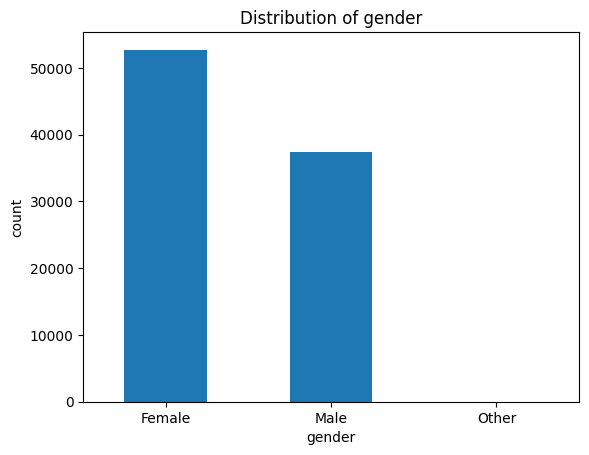

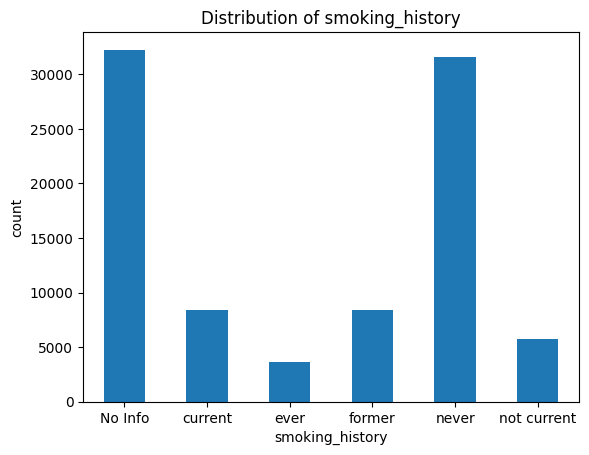

In [ ]:
for col in categorical_features:
    plt.title(f'Distribution of {col}')
    data[col].value_counts().sort_index().plot(kind='bar', rot=0, xlabel=col,ylabel='count')
    plt.show()
    print()

In [ ]:

male_data = data[data['gender'] == 'Male'].copy()
female_data = data[data['gender'] == 'Female'].copy()


male_data = male_data.drop(['gender'], axis=1)
female_data = female_data.drop(['gender'], axis=1)

print("Male data shape (after dropping gender):", male_data.shape)
print("Female data shape (after dropping gender):", female_data.shape)

Male data shape (after dropping gender): (37427, 8)
Female data shape (after dropping gender): (52721, 8)


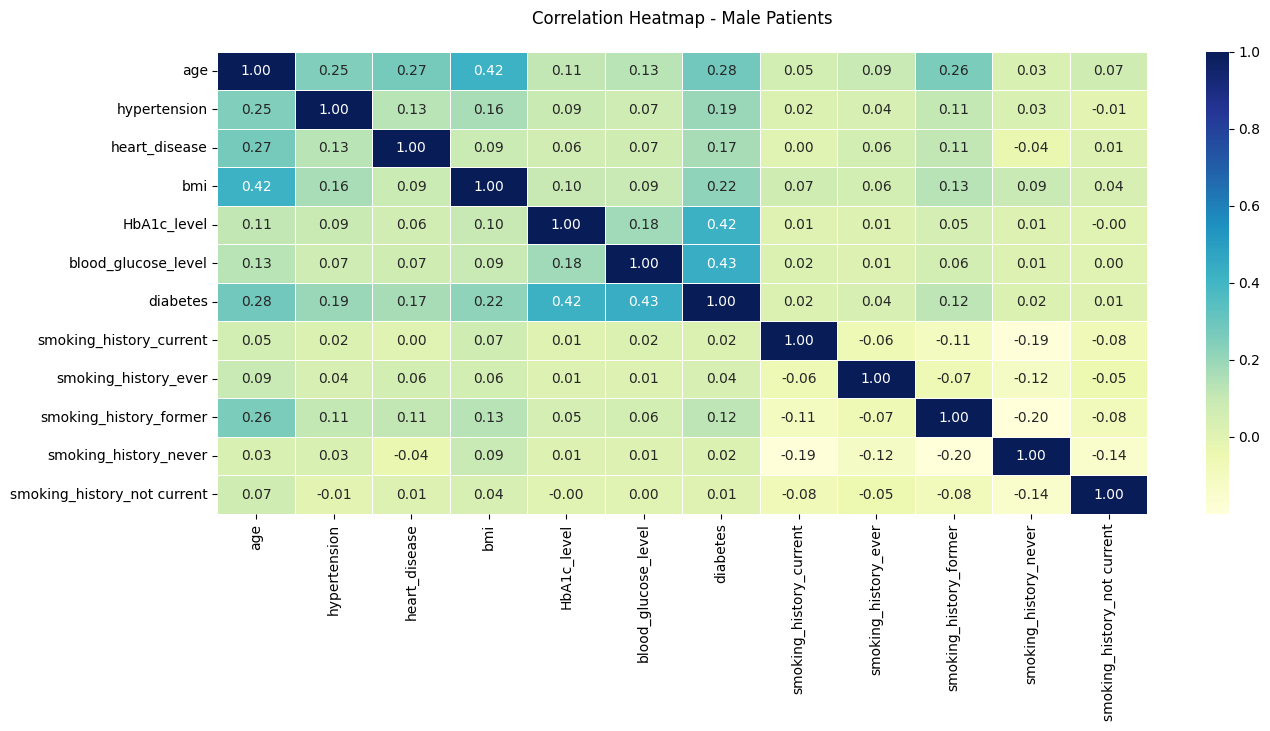

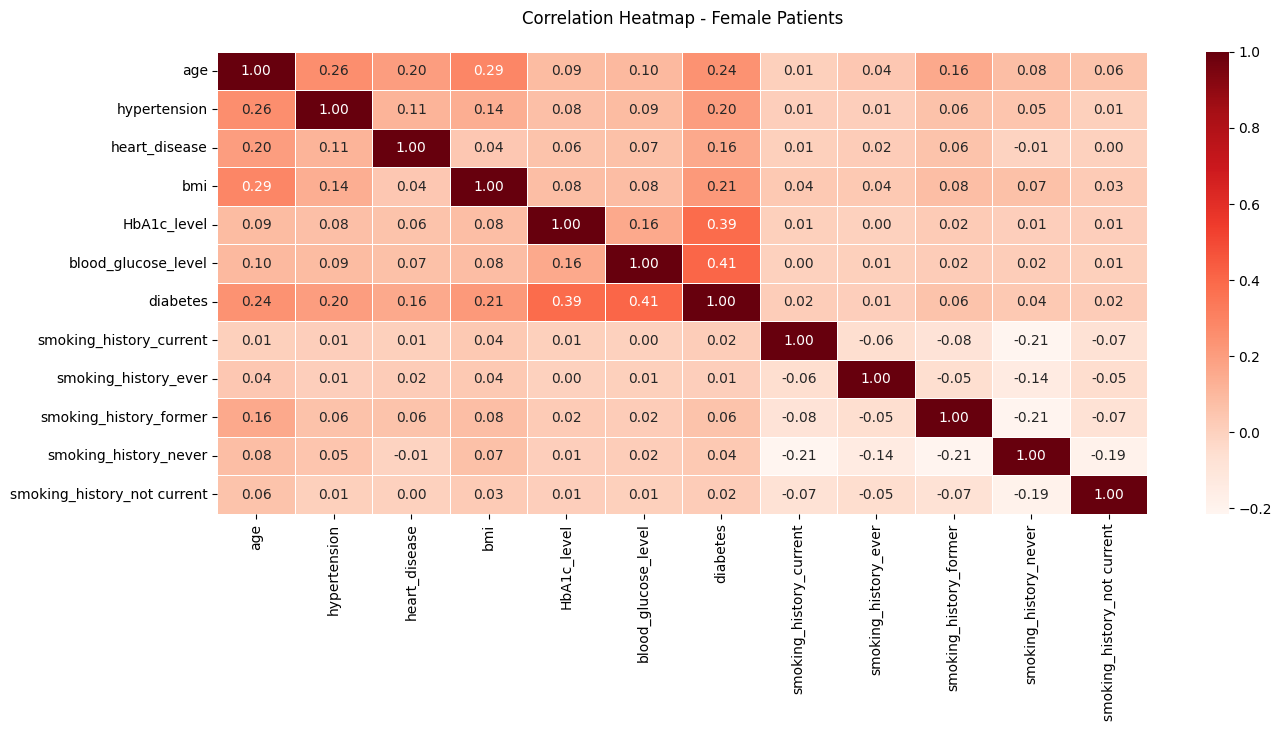

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


male_data_numeric = pd.get_dummies(male_data, drop_first=True)
female_data_numeric = pd.get_dummies(female_data, drop_first=True)


plt.figure(figsize=(15, 6))
sns.heatmap(male_data_numeric.corr(),
            annot=True,
            cmap='YlGnBu',
            fmt=".2f",
            linewidths=0.5)
plt.title("Correlation Heatmap - Male Patients", pad=20)
plt.show()


plt.figure(figsize=(15, 6))
sns.heatmap(female_data_numeric.corr(),
            annot=True,
            cmap='Reds',
            fmt=".2f",
            linewidths=0.5)
plt.title("Correlation Heatmap - Female Patients", pad=20)
plt.show()


In [ ]:
print("Missing values per column:")
print(data.isnull().sum())

Missing values per column:
gender                  9835
age                    10065
hypertension           10148
heart_disease           9919
smoking_history         9988
bmi                     9944
HbA1c_level            10139
blood_glucose_level     9880
diabetes               10082
dtype: int64


In [ ]:

for col in numerical_features:
    if data[col].isnull().any():
        mean_val = data[col].mean()
        data[col] = data[col].fillna(mean_val)


for col in categorical_features:
    if data[col].isnull().any():
        mode_val = data[col].mode()[0]
        data[col] = data[col].fillna(mode_val)


data['diabetes'] = data['diabetes'].astype(int)

print("Missing values after imputation:")
print(data.isnull().sum())

Missing values after imputation:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


In [ ]:
print("First 5 rows after imputation:")
display(data.head())

First 5 rows after imputation:


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.00000,0.0,1.0,never,25.19,6.600000,140.000000,0
1,Female,41.91052,0.0,0.0,No Info,27.32,6.600000,80.000000,0
2,Male,28.00000,0.0,0.0,never,27.32,5.528352,158.000000,0
3,Female,36.00000,0.0,0.0,No Info,23.45,5.000000,155.000000,0
4,Male,76.00000,1.0,1.0,current,20.14,4.800000,137.995018,0


In [ ]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd




X = data.drop('diabetes', axis=1)
y = data['diabetes']


onehot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_categorical_encoded = onehot_encoder.fit_transform(X[categorical_features])


encoded_feature_names = onehot_encoder.get_feature_names_out(categorical_features)


X_categorical_encoded_df = pd.DataFrame(X_categorical_encoded, columns=encoded_feature_names, index=X.index)


X_numeric = X.drop(columns=categorical_features)
X_processed = pd.concat([X_numeric, X_categorical_encoded_df], axis=1)

print("First 5 rows of features after one-hot encoding:")
display(X_processed.head())

print("\nInfo of features after one-hot encoding:")
X_processed.info()

First 5 rows of features after one-hot encoding:


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,gender_Female,gender_Male,gender_Other,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,80.00000,0.0,1.0,25.19,6.600000,140.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,41.91052,0.0,0.0,27.32,6.600000,80.000000,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,28.00000,0.0,0.0,27.32,5.528352,158.000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,36.00000,0.0,0.0,23.45,5.000000,155.000000,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,76.00000,1.0,1.0,20.14,4.800000,137.995018,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0



Info of features after one-hot encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   age                          100000 non-null  float64
 1   hypertension                 100000 non-null  float64
 2   heart_disease                100000 non-null  float64
 3   bmi                          100000 non-null  float64
 4   HbA1c_level                  100000 non-null  float64
 5   blood_glucose_level          100000 non-null  float64
 6   gender_Female                100000 non-null  float64
 7   gender_Male                  100000 non-null  float64
 8   gender_Other                 100000 non-null  float64
 9   smoking_history_No Info      100000 non-null  float64
 10  smoking_history_current      100000 non-null  float64
 11  smoking_history_ever         100000 non-null  float64
 12  smoking_history_f

Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd


numerical_cols_for_scaling = X_processed.columns[:len(numerical_features)-1]



scaler = StandardScaler()
X_processed[numerical_cols_for_scaling] = scaler.fit_transform(X_processed[numerical_cols_for_scaling])

print("First 5 rows of features after scaling numerical features:")
display(X_processed.head())

print("\nInfo of features after scaling:")
X_processed.info()

First 5 rows of features after scaling numerical features:


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,gender_Female,gender_Male,gender_Other,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,1.784592e+00,-0.301146,5.220214,-0.337030,1.055995e+00,5.203257e-02,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,3.329079e-16,-0.301146,-0.212656,0.001304,1.055995e+00,-1.505066e+00,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,-6.517444e-01,-0.301146,-0.212656,0.001304,8.752048e-16,5.191620e-01,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,-2.769234e-01,-0.301146,-0.212656,-0.613415,-5.206339e-01,4.413071e-01,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,1.597182e+00,3.695688,5.220214,-1.139182,-7.177125e-01,7.375898e-16,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0



Info of features after scaling:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   age                          100000 non-null  float64
 1   hypertension                 100000 non-null  float64
 2   heart_disease                100000 non-null  float64
 3   bmi                          100000 non-null  float64
 4   HbA1c_level                  100000 non-null  float64
 5   blood_glucose_level          100000 non-null  float64
 6   gender_Female                100000 non-null  float64
 7   gender_Male                  100000 non-null  float64
 8   gender_Other                 100000 non-null  float64
 9   smoking_history_No Info      100000 non-null  float64
 10  smoking_history_current      100000 non-null  float64
 11  smoking_history_ever         100000 non-null  float64
 12  smoking_history_former    

Data splitting

In [ ]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.3, random_state=42, stratify=y
)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

print("\nDistribution of target in y_train:")
print(y_train.value_counts(normalize=True))

print("\nDistribution of target in y_test:")
print(y_test.value_counts(normalize=True))

Shape of X_train: (70000, 15)
Shape of X_test: (30000, 15)
Shape of y_train: (70000,)
Shape of y_test: (30000,)

Distribution of target in y_train:
diabetes
0    0.923657
1    0.076343
Name: proportion, dtype: float64

Distribution of target in y_test:
diabetes
0    0.923667
1    0.076333
Name: proportion, dtype: float64


Model training

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


logreg_model = LogisticRegression(max_iter=1000)
logreg_model.fit(X_train, y_train)


y_pred_logreg = logreg_model.predict(X_test)


print("Classification Report for Logistic Regression:")
print(classification_report(y_test, y_pred_logreg))

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98     27710
           1       0.81      0.51      0.63      2290

    accuracy                           0.95     30000
   macro avg       0.89      0.75      0.80     30000
weighted avg       0.95      0.95      0.95     30000



In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report


nb_model = GaussianNB()
nb_model.fit(X_train, y_train)


y_pred_nb = nb_model.predict(X_test)


print("Classification Report for Gaussian Naive Bayes:")
print(classification_report(y_test, y_pred_nb))

Classification Report for Gaussian Naive Bayes:
              precision    recall  f1-score   support

           0       0.99      0.59      0.74     27710
           1       0.16      0.96      0.28      2290

    accuracy                           0.62     30000
   macro avg       0.58      0.78      0.51     30000
weighted avg       0.93      0.62      0.71     30000



In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import classification_report


model_nn = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile the model
model_nn.compile(optimizer='adam',
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

# Train the model
print("Training Neural Network...")
history_nn = model_nn.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=0)
# Evaluate the model
print("\nEvaluating Neural Network...")
loss_nn, accuracy_nn = model_nn.evaluate(X_test, y_test, verbose=0)
print(f"\nNeural Network Accuracy (Test Data): {accuracy_nn}")

# Predict on the test set for classification report
y_pred_nn_proba = model_nn.predict(X_test)
y_pred_nn = (y_pred_nn_proba > 0.5).astype("int32")

print("\nClassification Report for Neural Network:")
print(classification_report(y_test, y_pred_nn))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training Neural Network...

Evaluating Neural Network...

Neural Network Accuracy (Test Data): 0.9637666940689087
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

Classification Report for Neural Network:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     27710
           1       0.85      0.63      0.73      2290

    accuracy                           0.96     30000
   macro avg       0.91      0.81      0.85     30000
weighted avg       0.96      0.96      0.96     30000



Model selection/Comparison analysis


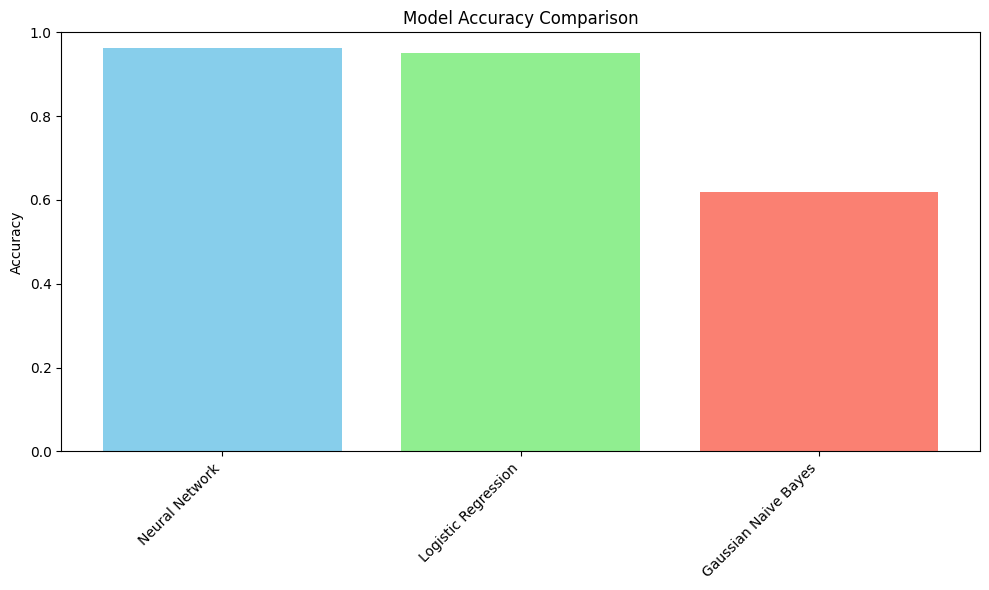

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


logreg_accuracy = 0.95


nb_accuracy = 0.62


nn_accuracy = accuracy_nn

# Create a DataFrame for easy plotting
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Gaussian Naive Bayes', 'Neural Network'],
    'Accuracy': [logreg_accuracy, nb_accuracy, nn_accuracy]
})

# Sort by accuracy
model_comparison = model_comparison.sort_values(by='Accuracy', ascending=False)

# Create the bar plot
plt.figure(figsize=(10, 6))
plt.bar(model_comparison['Model'], model_comparison['Accuracy'], color=['skyblue', 'lightgreen', 'salmon'])
plt.ylim(0, 1) # Accuracy is between 0 and 1
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

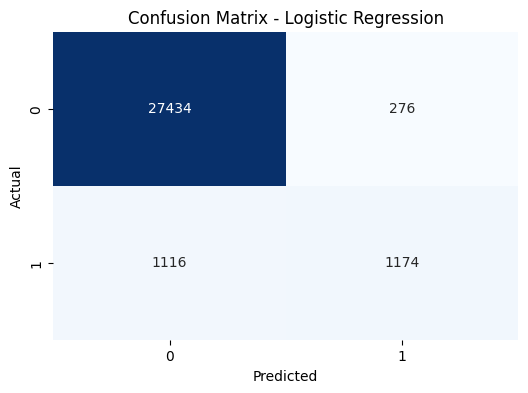

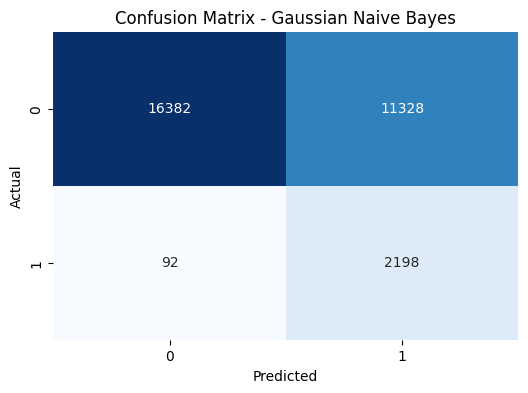

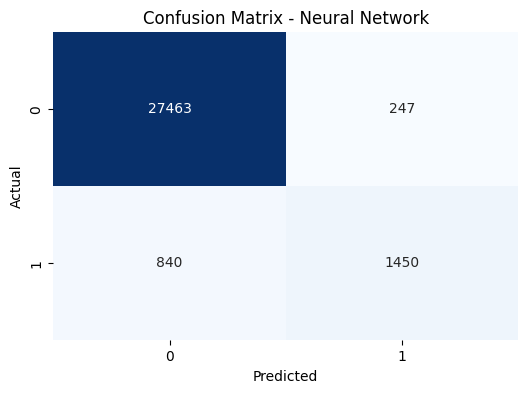

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix for Logistic Regression
cm_logreg = confusion_matrix(y_test, y_pred_logreg)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_logreg, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Confusion Matrix for Gaussian Naive Bayes
cm_nb = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Gaussian Naive Bayes')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Confusion Matrix for Neural Network
cm_nn = confusion_matrix(y_test, y_pred_nn)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Neural Network')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


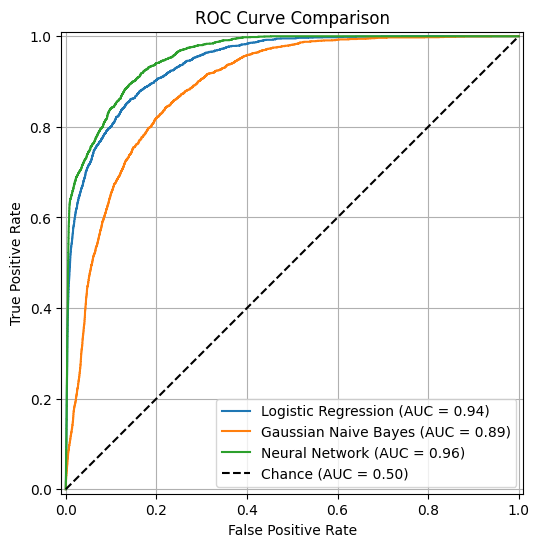

AUC Score - Logistic Regression: 0.9426
AUC Score - Gaussian Naive Bayes: 0.8891
AUC Score - Neural Network: 0.9567


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

# Calculate ROC AUC and plot ROC curve for Logistic Regression
y_pred_logreg_proba = logreg_model.predict_proba(X_test)[:, 1] # Get probabilities for the positive class
auc_logreg = roc_auc_score(y_test, y_pred_logreg_proba)
fpr_logreg, tpr_logreg, _ = roc_curve(y_test, y_pred_logreg_proba)
roc_display_logreg = RocCurveDisplay(fpr=fpr_logreg, tpr=tpr_logreg, roc_auc=auc_logreg, estimator_name='Logistic Regression')

# Calculate ROC AUC and plot ROC curve for Gaussian Naive Bayes
y_pred_nb_proba = nb_model.predict_proba(X_test)[:, 1] # Get probabilities for the positive class
auc_nb = roc_auc_score(y_test, y_pred_nb_proba)
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_pred_nb_proba)
roc_display_nb = RocCurveDisplay(fpr=fpr_nb, tpr=tpr_nb, roc_auc=auc_nb, estimator_name='Gaussian Naive Bayes')


#
y_pred_nn_proba = model_nn.predict(X_test).ravel()
auc_nn = roc_auc_score(y_test, y_pred_nn_proba)
fpr_nn, tpr_nn, _ = roc_curve(y_test, y_pred_nn_proba)
roc_display_nn = RocCurveDisplay(fpr=fpr_nn, tpr=tpr_nn, roc_auc=auc_nn, estimator_name='Neural Network')


# Plot all ROC curves on the same graph
fig, ax = plt.subplots(figsize=(8, 6))

roc_display_logreg.plot(ax=ax)
roc_display_nb.plot(ax=ax)
roc_display_nn.plot(ax=ax)


plt.title('ROC Curve Comparison')
plt.plot([0, 1], [0, 1], 'k--', label='Chance (AUC = 0.50)') # Plot the diagonal chance line
plt.legend()
plt.grid()
plt.show()

print(f"AUC Score - Logistic Regression: {auc_logreg:.4f}")
print(f"AUC Score - Gaussian Naive Bayes: {auc_nb:.4f}")
print(f"AUC Score - Neural Network: {auc_nn:.4f}")

In [ ]:
import pandas as pd
from sklearn.metrics import classification_report


logreg_report = classification_report(y_test, y_pred_logreg, output_dict=True)
logreg_precision = logreg_report['1']['precision']
logreg_recall = logreg_report['1']['recall']


nb_report = classification_report(y_test, y_pred_nb, output_dict=True)
nb_precision = nb_report['1']['precision']
nb_recall = nb_report['1']['recall']


nn_report = classification_report(y_test, y_pred_nn, output_dict=True)
nn_precision = nn_report['1']['precision']
nn_recall = nn_report['1']['recall']


metrics_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Gaussian Naive Bayes', 'Neural Network'],
    'Precision (Class 1)': [logreg_precision, nb_precision, nn_precision],
    'Recall (Class 1)': [logreg_recall, nb_recall, nn_recall]
})

print("Precision and Recall Comparison (for Diabetes=1):")
display(metrics_comparison)

Precision and Recall Comparison (for Diabetes=1):


,Model,Precision (Class 1),Recall (Class 1)
0,Logistic Regression,0.809655,0.512664
1,Gaussian Naive Bayes,0.162502,0.959825
2,Neural Network,0.854449,0.633188


Unsupervised

Kmeans clustering

In [ ]:
from sklearn.cluster import KMeans


n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10) # Added n_init for robustness
clusters = kmeans.fit_predict(X_processed)


data_with_clusters = data.copy()
data_with_clusters['cluster'] = clusters

print(f"Added cluster labels to data_with_clusters with {n_clusters} clusters.")
print("First 5 rows of data with cluster labels:")
display(data_with_clusters.head())

Added cluster labels to data_with_clusters with 3 clusters.
First 5 rows of data with cluster labels:


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes,cluster
0,Female,80.00000,0.0,1.0,never,25.19,6.600000,140.000000,0,1
1,Female,41.91052,0.0,0.0,No Info,27.32,6.600000,80.000000,0,2
2,Male,28.00000,0.0,0.0,never,27.32,5.528352,158.000000,0,2
3,Female,36.00000,0.0,0.0,No Info,23.45,5.000000,155.000000,0,2
4,Male,76.00000,1.0,1.0,current,20.14,4.800000,137.995018,0,1
